# Assignment 2 (25%)

### Part 1 (6 marks)

### Answer
I am going to choose the coupled dynamical system of **the SIR model** for epidemic spread, aiming to investigate a scenario that cannot be captured by the current base model.

#### Scenario

There is a shipwreck where the survivors are swimming towards a single lifeboat. Initially, when a few individuals board it, the lifeboat can support them with stability and safety. However, as more and more individuals attempt to board, the lifeboat is packed to capacity. It becomes increasingly difficult to transport them all, and the chances of individual survival begin to dwindle.

This situation is an analogy to the healthcare system during an epidemic. Hospitals can manage the patient flow and provide appropriate treatment in the early stages of an outbreak. But once the number of affected individuals is on the rise, the health systems are overstretched and face a decline in the quality of treatment, with decreased recovery rates.

Lifeboat = Healthcare system

Survivors swimming to the lifeboat = Infected individuals requiring hospitalization


#### Question

**What if the chance of survival decreases when the lifeboat is overloaded?**

Similarly, **What if the recovery rate decreases when hospitals are overwhelmed?**

#### Base Model: The SIR Model
The base SIR model is a mathematical model for an infectious disease by dividing individuals into three compartments

$S(t)$: Susceptible individuals

$I(t)$: Infected individuals

$R(t)$: Recovered individuals

#### Equation (Continuous Time)
Susceptible individuals become infected when they encounter individuals at rate $\beta$.
$$\frac{dS}{dt} = -\beta SI$$

Infected individuals recover at a constant rate $\alpha$.
$$\frac{dI}{dt} = \beta SI - \alpha I$$

Recovered individuals increase at a rate $\alpha$ and become immune. This base model assumes a constant recovery rate $\alpha$. 
$$\frac{dR}{dt} = \alpha I$$

#### Extensions
#### 1: Make $\gamma$ a function of ${I}$
- Changing a model parameter into a function of a variable

As the number of infected patients ${I(t)}$ grows, the healthcare system becomes overwhelmed, and patients take longer to recover. We make the recovery rate $\gamma(I)$ smaller as ${I}$ grows larger.

$$\gamma(I) = \frac{\gamma_0}{1+\alpha I}$$

$\gamma_0$ = base recovery rate

$\alpha$ = sensitivity of the system (higher $\alpha$ = faster collapse of healthcare)

#### 2: Add a new variable for hospitalised population $H(t)$
- Introduce a new variable

$H(t)$ = number of individuals in the hospital due to being infected, to trace hospital pressure specifically, healthcare stress factor (larger $\alpha$ will have more sensitive slowdown)

These are a subset of the infected population $I(t)$, since not all infected people are hospitalised, and one of the key constraints during epidemics is hospital capacity.

Here we are modelling how the hospital becomes full and empties over time

**Equation**
$$
\frac{dH}{dt} = pI - ηH
$$

$pI$ = Patients enter the hospital (Inflow into hospital). This will increase the H.

$p$ is hospitalization rate per infected person

$ηH$ = Patients exit from hospital (Outflow from hospital), where patients leave the hospital due to recovery, death or transfer. This will decrease the H.

$η$ is the discharge rate from the hospital

Adjusting the recovery rate γ according to hospital pressure,

$$\gamma(H) = \frac{\gamma_0}{1 + \alpha H}$$

When $H$ is low, the recovery is fast

When $H$ is high, the recovery slows down ($\gamma$ drops), because healthcare quality drops

#### Updated System of Equations
$$\frac{dS}{dt} = - \beta S I$$

$$\frac{dI}{dt} = \beta S I - \gamma (H) I$$

$$\frac{dR}{dt} = \gamma (H) I $$

$$\frac{dH}{dt} = pI - ηH $$

$$\gamma(H) = \frac{\gamma_0}{1+\alpha H} $$

#### Assumptions
1. Closed population: no births, deaths (apart from disease), or migration.

2. A fixed proportion ρ of infected individuals are hospitalised.

3. Hospital discharge is at a constant rate η.

4. Recovery rate γ depends only on the current hospital load H (not on I directly).

5. Recovered individuals are immune and do not rejoin the susceptible group.

Including hospital load $H(t)$, we are able to simulate how overcrowded healthcare systems reduce recovery efficiency. The higher the infections, the higher the hospitalizations and induce slow recovery and more infections which generate second waves, longer epidemics or critical collapse points.

### Part 2 (6 marks) - Discrete time analysis

### Answer
Let the variables at time step t be:

$S_{t}, I_{t}, R_{t}, H_{t}$

And define:

$$\gamma_{t} = \frac{\gamma_{0}}{1+\alpha H_{t}}$$

Approximate derivatives using differences
$$\frac{dS}{dt} \approx S_{k+1} - S_{k}$$

$$\frac{dI}{dt} \approx I_{k+1} - I_{k}$$

$$\frac{dR}{dt} \approx R_{k+1} - R_{k}$$

#### Discrete Time Equations

Infected people are produced from contact between $S$ and $I$.

$S_{t+1} = S_{t} - \beta S_{t} I_{t}$

Infected grow by infections, and decrease by recovery.

$I_{t+1} = I_{t} + \beta S_{t}I_{t} - \alpha_{t}I_{t}$

Recoveries happen at a rate of $\alpha$

$R_{t+1} = R_{t} + \alpha_{t} I_{t}$

Hospitalisations grow with infected and decrease by discharges.

$H_{t+1} = H_{t} + pI_{t} - η H_{t}$

Recovery rate slows down when H is high.

$\alpha_{t} = \frac {\alpha_{0}}{1+\alpha H_{t}}$


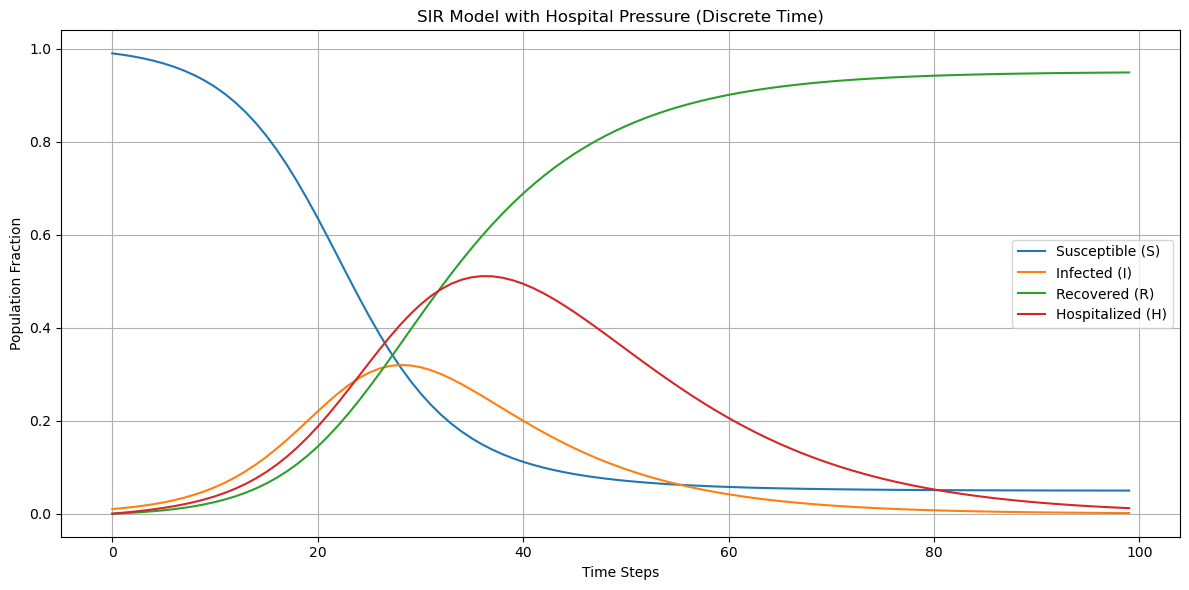

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Time horizon
T = 100 # days

# Parameters
beta = 0.3 # moderate infection rate
gamma_0 = 0.1 # baseline recovery rate
alpha = 0.05 # healthcare collapses gradually
rho = 0.2 # 20% of infected get hospitalized
eta = 0.1 # hospital stay lasts ~ 10 days

# Initialize arrays
S = np.zeros(T)
I = np.zeros(T)
R = np.zeros(T)
H = np.zeros(T)
gamma = np.zeros(T)

# Initial conditions
S[0] = 0.99
I[0] = 0.01
R[0] = 0.0
H[0] = 0.0

# Simulate the system
for t in range(T - 1):
    gamma[t] = gamma_0 / (1 + alpha * H[t])
    S[t+1] = S[t] - beta * S[t] * I[t]
    I[t+1] = I[t] + beta * S[t] * I[t] - gamma[t] * I[t]
    R[t+1] = R[t] + gamma[t] * I[t]
    H[t+1] = H[t] + rho * I[t] - eta * H[t]

# Compute the final gamma value
gamma[-1] = gamma_0 / (1 + alpha * H[-1])

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(S, label="Susceptible (S)")
plt.plot(I, label="Infected (I)")
plt.plot(R, label="Recovered (R)")
plt.plot(H, label="Hospitalized (H)")
plt.title("SIR Model with Hospital Pressure (Discrete Time)")
plt.xlabel("Time Steps")
plt.ylabel("Population Fraction")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Interpretation of the Results:
From the plot, 

Infected ($I$) rises quickly first — similarly in an epidemic.

Hospitalized ($H$) begins low but rises with $I$, showing hospital burden.

As H rises, recovery rate $\gamma(H)$ falls — which slows down the rate of fall of $I$.

Susceptible ($S$) falls steadily as infection spreads to more individuals.

Recovered ($R$) increases, but more slowly than in the base SIR model as recovery rates are lower when H is high.

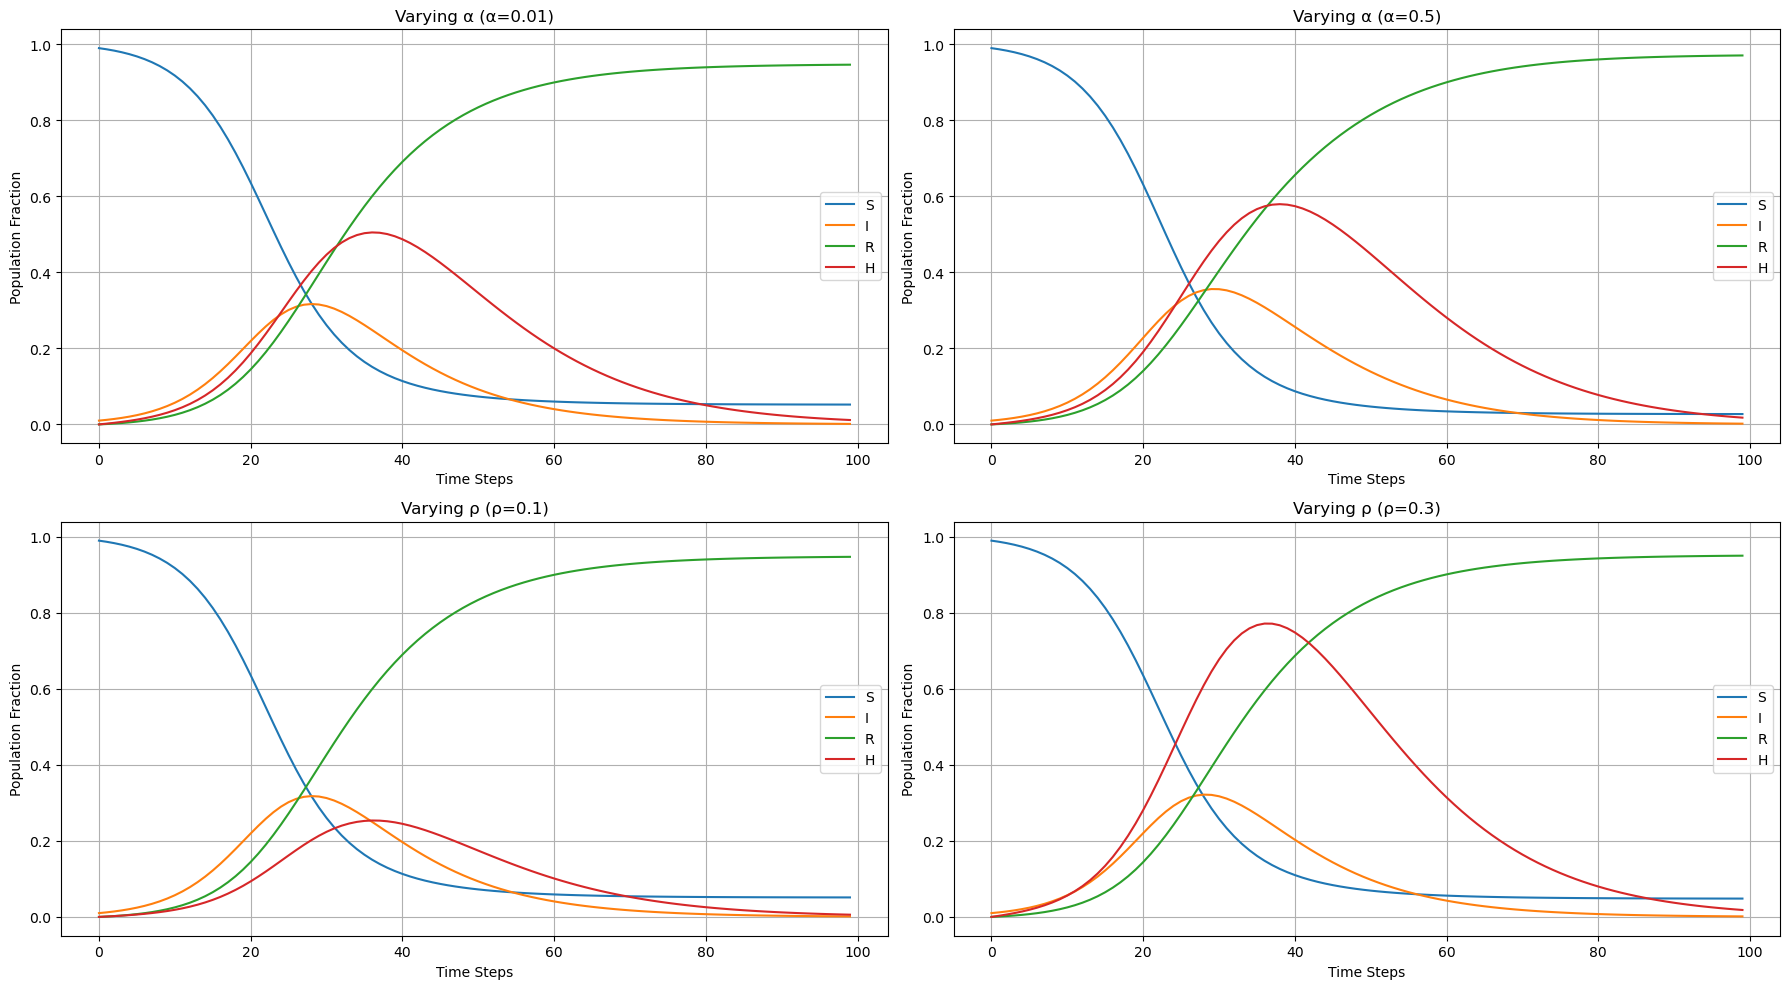

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Function to simulate the discrete-time model
def simulate_sir_hospital_discrete(T, beta, gamma_0, alpha, rho, eta):
    S = np.zeros(T)
    I = np.zeros(T)
    R = np.zeros(T)
    H = np.zeros(T)
    gamma = np.zeros(T)

    # Initial conditions
    S[0] = 0.99
    I[0] = 0.01
    R[0] = 0.0
    H[0] = 0.0

    for t in range(T - 1):
        gamma[t] = gamma_0 / (1 + alpha * H[t])
        S[t+1] = S[t] - beta * S[t] * I[t]
        I[t+1] = I[t] + beta * S[t] * I[t] - gamma[t] * I[t]
        R[t+1] = R[t] + gamma[t] * I[t]
        H[t+1] = H[t] + rho * I[t] - eta * H[t]

    gamma[-1] = gamma_0 / (1 + alpha * H[-1])
    return S, I, R, H

# Parameters
T = 100 # days
beta = 0.3 # Transmission rate
gamma_0 = 0.1 # Base recovery rate
eta = 0.1 # Hospital discharge rate

# Parameter variations
alpha_values = [0.01, 0.5] # healthcare collaspe gradually
rho_values = [0.1, 0.3] # percentage of infected get hospitalized

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
for i, alpha in enumerate(alpha_values):
    S, I, R, H = simulate_sir_hospital_discrete(T, beta, gamma_0, alpha, 0.2, eta)
    ax = axes[0, i]
    ax.plot(S, label="S")
    ax.plot(I, label="I")
    ax.plot(R, label="R")
    ax.plot(H, label="H")
    ax.set_title(f"Varying α (α={alpha})")
    ax.set_xlabel("Time Steps")
    ax.set_ylabel("Population Fraction")
    ax.legend()
    ax.grid(True)

for i, rho in enumerate(rho_values):
    S, I, R, H = simulate_sir_hospital_discrete(T, beta, gamma_0, 0.05, rho, eta)
    ax = axes[1, i]
    ax.plot(S, label="S")
    ax.plot(I, label="I")
    ax.plot(R, label="R")
    ax.plot(H, label="H")
    ax.set_title(f"Varying ρ (ρ={rho})")
    ax.set_xlabel("Time Steps")
    ax.set_ylabel("Population Fraction")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


#### Interpretation
The $\alpha$ parameter controls how much hospital load (H) reduces the recovery rate ($\gamma$). Comparing $\alpha$ = 0.01 and $\alpha$ = 0.5 on the model, when $\alpha$ is high (0.5), H(t) will significantly slow down recovery as $\gamma$ decreases. Moreover, there is higher peak infections; I(t) curve will decline more slowly leading to longer epidemic. 

The $\rho$ parameter controls the hospitalization rate. Comparing $\rho$ = 0.1 and $\rho$ = 0.3 on the model, when $\rho$ is low, fewer people enter hospitals (H curve is low), more people remain in infected pool while when $\rho$ is high, more infected people go to hospital (H curve spikes higher) which helps reduce infections. 

#### Conclusion
The extended model shows that when hospital systems collapse, recovery is significantly delayed, making infectious periods longer, infection peaks higher and overall epidemic resolution slower. In both scenarios, the susceptible population (S) decreases as people get infected and recover

### Part 3 (7 marks) - Continuous time analysis

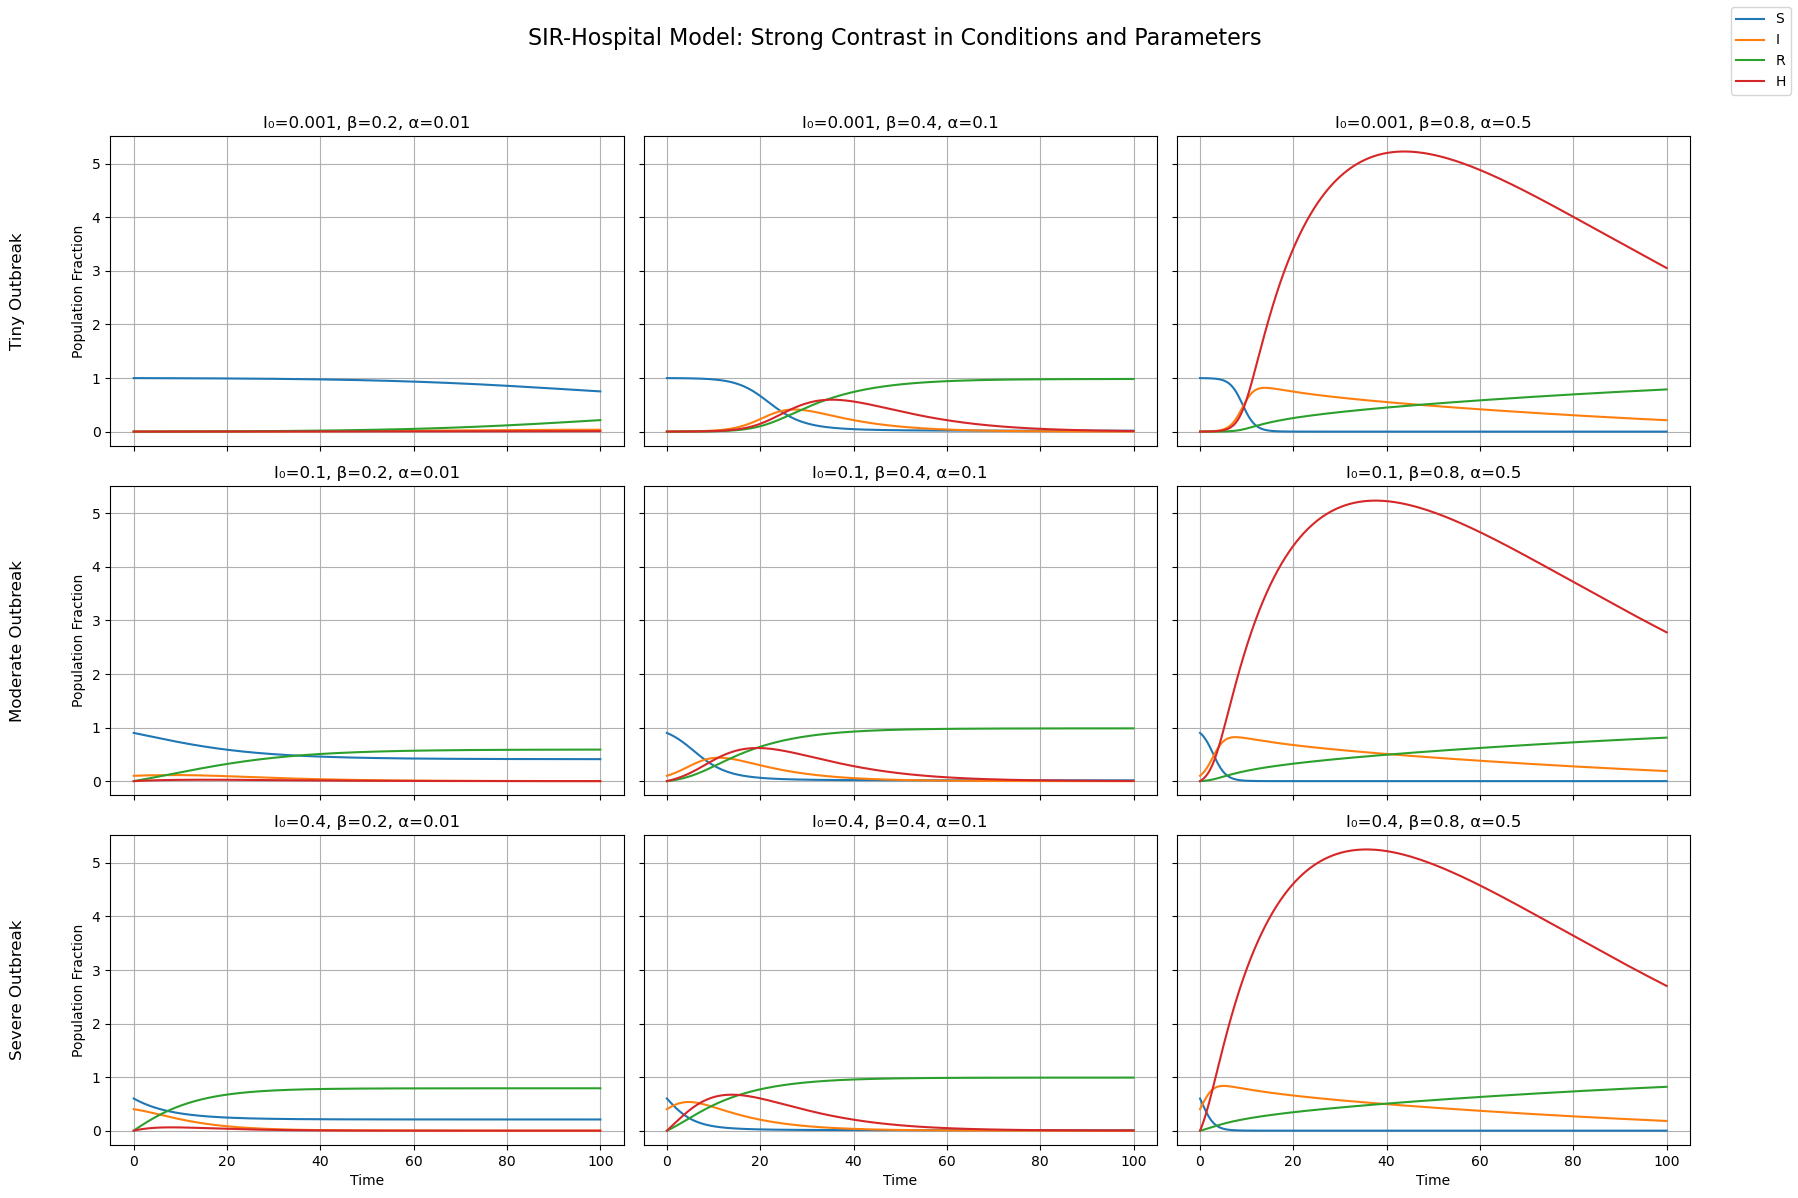

In [4]:
from scipy.integrate import solve_ivp

# Define the system of differential equations
def sir_hospital_model(t, y, beta, gamma_0, alpha, rho, eta):
    S, I, R, H = y
    gamma = gamma_0 / (1 + alpha * H)
    dSdt = -beta * S * I
    dIdt = beta * S * I - gamma * I
    dRdt = gamma * I
    dHdt = rho * I - eta * H
    return [dSdt, dIdt, dRdt, dHdt]

# Initial conditions
initial_conditions = [
    [0.999, 0.001, 0.0, 0.0],  # Tiny outbreak
    [0.90, 0.10, 0.0, 0.0],    # Moderate outbreak
    [0.60, 0.40, 0.0, 0.0]     # Severe outbreak
]

# Parameters
parameter_sets = [
    # Slow spread, low hospitalization
    {'beta': 0.2, 'gamma_0': 0.15, 'alpha': 0.01, 'rho': 0.05, 'eta': 0.2},

    # Moderate spread, moderate hospitalization
    {'beta': 0.4, 'gamma_0': 0.1,  'alpha': 0.1,  'rho': 0.2,  'eta': 0.1},

    # Aggressive spread, high hospitalization impact
    {'beta': 0.8, 'gamma_0': 0.05, 'alpha': 0.5,  'rho': 0.5,  'eta': 0.05}
]

t_span = (0, 100)
t_eval = np.linspace(*t_span, 500)

fig, axs = plt.subplots(len(initial_conditions), len(parameter_sets), figsize=(18, 12), sharex=True, sharey=True)

row_titles = ['Tiny Outbreak', 'Moderate Outbreak', 'Severe Outbreak']

for i, y0 in enumerate(initial_conditions):
    for j, params in enumerate(parameter_sets):
        sol = solve_ivp(sir_hospital_model, t_span, y0, t_eval=t_eval, args=tuple(params.values()), method='RK45')
        S, I, R, H = sol.y

        ax = axs[i][j] if len(initial_conditions) > 1 else axs[j]
        ax.plot(sol.t, S, label='S')
        ax.plot(sol.t, I, label='I')
        ax.plot(sol.t, R, label='R')
        ax.plot(sol.t, H, label='H')
        ax.set_title(f"I₀={y0[1]}, β={params['beta']}, α={params['alpha']}")
        ax.grid(True)

        if i == len(initial_conditions) - 1:
            ax.set_xlabel('Time')
        if j == 0:
            ax.set_ylabel('Population Fraction')
            ax.annotate(row_titles[i], xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 30, 0),
                        xycoords=ax.yaxis.label, textcoords='offset points',
                        size='large', ha='right', va='center', rotation=90)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')
fig.suptitle("SIR-Hospital Model: Strong Contrast in Conditions and Parameters", fontsize=16)
plt.tight_layout(rect=[0, 0, 0.95, 0.95])
plt.show()

The system's behaviour is significantly impacted by parameters β (infection rate) and α (hospitalisation feedback effect).

#### Small Outbreaks($I_0$ = 0.001)

**Mild parameters ($\beta$ = 0.2, $\alpha$ = 0.01)**

Low hospital burden leading to slow rise in infections, a small peak, and a smooth recovery with low hospitalisations.

**Moderate parameters ($\beta$ = 0.4, $\alpha$ = 0.1)**

Exhibits moderate spread and feedback, creating a clear wave where hospitalisations (H) rise and recovery slowed down by the α effect, potentially creating a second wave. 

**Severe parameters ($\beta$ = 0.8, $\alpha$ = 0.5)**

The outbreak is aggressive and heavily dependent on hospital capacity, with an initial small bump triggering a large outbreak. Hospitalisations surge sharply, and the strong feedback effect (α) significantly inhibits recovery, delaying and amplifying the infection peak while prolonging the recovery period.

#### Moderate Outbreaks($I_0$ = 0.1)

**Mild parameters ($\beta$ = 0.2, $\alpha$ = 0.01)**

The disease spreads mildly but faster than in Row 1, leading to a higher buildup of infections that remains under control, with hospitalizations (H) increasing moderately. 

**Moderate parameters ($\beta$ = 0.4, $\alpha$ = 0.1)**

As feedback effects engage earlier, exerting pressure on hospital capacity earlier and preventing recovery.

**Severe parameters ($\beta$ = 0.8, $\alpha$ = 0.5)**

The epidemic is severe as hospitals are overwhelmed, causing the recovery rate to drop and infections to surge uncontrollably. Hospitalisations are rising dramatically and dominating the system for an extended period. The transmission rate and hospital capacity become the deciding factors on what occurs with the outbreak. 

#### Severe outbreak scenario ($I_0$ =0.40)

**Mild parameters ($\beta$ = 0.2, $\alpha$ = 0.01)**

The parameters fail to suppress the outbreak where the susceptibles (S) drop rapidly, infections (I) increase to high levels, and recoveries (R) only grow later on, with hospitalisations (H) surge beyond the system's capacity. 

**Moderate parameters ($\beta$ = 0.4, $\alpha$ = 0.1)**

Exhibits a significant pandemic-like wave, with S decreasing very early, hospitals breaking over capacity, and infections persisting for an extended period before declining. 

**Severe parameters ($\beta$ = 0.8, $\alpha$ = 0.5)**

Represents a catastrophic surge where infections (I) and hospitalisations (H) escalate rapidly. Hospital overload severely slows recovery, allowing infections to spread to the population and causing a decline in the susceptible population. The outbreak's severity overwhelms the system. 


#### Conclusion
Continuous-time uses smooth differential equations solved with numerical integrators like Runge-Kutta (more accurate), while discrete-time uses step-by-step updates (simpler, but less accurate). Both models illustrate higher hospital feedback ($\alpha$) and higher hospitalisation rates ($\rho$), slow recovery and prolonged outbreaks by healthcare system strain. 

When hospital systems become overwhelmed (high $H$), it will reduce recovery efficiency (low $\gamma$), keeping infections high, leading to higher and longer infection peaks, hospital loads and less efficient epidemic resolution. This shows how important hospital capacity is when dealing with big outbreaks.

### Part 4 (6 marks) - Steady state analysis

$\frac{dS}{dt}$ = $\frac{dI}{dt}$ = $\frac{dR}{dt}$ = $\frac{dH}{dt}$ = 0

$\frac{dS}{dt}$ = -$\beta$$SI$ = 0. 
Thus, $S$ = 0 or $I$ = 0

$\frac{dI}{dt}$ = $\beta$$SI$ - $\gamma$$(H)I$ = 0. 
Thus, $I$ = 0 or $\beta$$S$ = $\gamma$$(H)$

$\frac{dR}{dt}$ = $\gamma$$(H)I$ = 0. 
Thus, $I$ = 0 or $\gamma$$(H)$ = 0

$\frac{dH}{dt}$ = $\rho$$I$ - $\eta$$H$= 0. 
Thus, $\rho$$I$ = $\eta$$H$

So, the system has two meaningful steady state

**Disease-Free Steady State: I = 0**

$I$ = 0 (no infection), $H$ = 0 (no hospitalization)

R may be nonzero, S can be any value between 0 and 1 (depending on how much of the population was already infected and recovered)

This represents the end of the epidemic: no more infections, no hospitalizations.

This steady state is stable if after a small introduction of infection, the disease dies out. Usually happends when the remaining susceptible fraction S is too small to sustain transmission

Specifically, if $\beta$$S$ < $\gamma_0$, infection rate < recovery rate, thus infection cannot grow.

**Endemic Steady State: I $\not=$ 0**

From $\frac{dS}{dt}$ = 0: Since $I$ $\not=$ 0, we must have $S$ = 0

But if $S$ = 0, from $\frac{dI}{dt}$ = 0, $\beta$$SI$ - $\gamma(H)I$ = - $\gamma(H)I$ = 0. Thus, $\gamma(H)$ = 0 (since $I$ $\not=$ 0)

From $\frac{dR}{dt}$ = 0, $\gamma(H)I$ = 0. Thus, $\gamma(H)$ = 0

From $\frac{dH}{dt}$ = 0, $\rho$$I$ = $\eta$$H$. Thus, $H$ = $\frac{\rho I}{\eta}$

If $\beta$$S$ = $\gamma(H)$ while $I$ $\not=$ 0, infection can be maintained at a low level indefinitely

If $\gamma(H)$ = 0, the recovery rate $\gamma$ is 0 when $H$ = $\frac{\rho I}{\eta}$. This is unrealistic unless $\gamma$ is a function which can be 0 for some $H$ since it tends to drive $I$ to zero eventually unless $\beta$ is quite high and $\gamma_0$ is quite low

For standard models where $\gamma(H)$ > 0, the only equilibrium is when disease-free equilibrium.

If $S$ is reduced low enough (by previous infections) so that $\beta$$S$ < $\gamma_0$, then any small number of infections will die out which cause the disease-free equilibrium to be stable

If $\beta$$S$ > $\gamma_0$ even after a lot of infections, small infection could restart an outbreak which cause the disease-free equilibrium to be unstable

#### How This Answer Part 1 (Lifeboat Analogy)
In the early stages, when there are only a few infections, the hospital system (lifeboat) can manage patients effectively, similarly to a lifeboat carrying the patients safely. When infections rise, the pressure on hospitals begins to slow recovery, causing a dangerous feedback loop that delays recovery and allows the disease to spread further.  But then, after a while, as sufficiently many individuals recover (or die), the susceptible individuals decline which causes the reduction of infections, reducing hospital burden and allowing recovery rates to accelerate again. Eventually, the system reaches a stable, disease-free steady state, but the path to stability can involve large hospital overloads, second waves, or even near-collapse, depending on parameter values (β, α, etc.).

# AI Statement

I acknowledge the use of ChatGPT(https://chat.openai.com/) 
##### i) To refine my own work and academic language
I submitted the analysis I wrote for each plot with instructions to improve my phrasing, vocabulary, and language accuracy (2 iterations). I further rephrased to represent my tone and style of writing.

##### ii) To help clarify the concepts related to the SIR model
I asked Chatgpt about the differences between discrete-time and continuous-time simulations. It help me understand complex concepts. (4 iterations)

##### iii) To help debug code, setting axis labels
I submitted my code and used GPT to set up the axis labels and debug my code. Here is the google document where it stated my prompt and the output: https://docs.google.com/document/d/1CJF6aIM_OtY6-l6myfnkMnj5u1IX62Qkri5VodCgSe8/edit?usp=sharing